# Caso A - Predicción de Abandono de Clientes - App Digital
***Autores:*** Grupo G: Giovanni Cabrera y Rolando de Jesus Pineda

## 1. Descripción del problema de negocio

La institución financiera busca reducir el abandono de clientes en su aplicación digital. Identificar oportunamente a los clientes con mayor riesgo de abandono permitirá ejecutar acciones de retención, mejorar la experiencia digital y enfocar los esfuerzos comerciales en los clientes más relevantes.

## Mapa de selección de algoritmos
### Paso 1: Tipo de variable objetivo
La variable objetivo es **abandono**, con valores Si y No. Por consiguiente, se trata de un problema de **clasificación binaria**.
### Paso 2: Objetivo de negocio y familia de algoritmos
El objetivo es identificar clientes con riesgo de abandono para tomar acciones preventivas. Las familias de algoritmos aplicables incluyen Regresión Logística y Random Forest.
### Paso 3: Análisis de límites y riesgos
Se evalua Overfitting, Sesgo e Interpretabilidad
### Paso 4: Consideraciones éticas
Se considera sesgos, transparencia con los stakeholders y privacidad de los clientes
### Paso 5 (Final): Conclusiones y recomendaciones
Finalmente se hace la recomendación de un modelo en el que se aplica una de los algoritmos evaluados 

## Carga del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("data\dataset_churn_app_financiera_500.csv")
df.head()

,cliente_id,genero,rango_edad,distrito,tipo_cliente,monto_promedio_mensual,cantidad_transacciones_mes,tipo_transaccion_frecuente,frecuencia_uso_app,sesiones_mes,...,interaccion_promociones,promociones_abiertas,cantidad_quejas,ultima_queja_dias,productos_activos,uso_biometria,notificaciones_activas,uso_pago_servicios,uso_transferencias,abandono
0,C0001,Masculino,18-25,Santa Tecla,Plata,242,12,PagoServicios,8,44,...,Ninguna,8,0,309,1,Si,No,Si,No,Si
1,C0002,Femenino,18-25,San Miguel,Oro,2139,49,Transferencias,12,14,...,Alta,5,0,310,3,Si,No,Si,No,No
2,C0003,Masculino,60+,Santa Tecla,Oro,4627,6,Mixto,8,37,...,Alta,4,5,41,2,Si,No,No,No,No
3,C0004,Femenino,26-35,Mejicanos,Plata,786,69,Mixto,8,44,...,Media,2,0,237,4,No,Si,No,Si,No
4,C0005,Masculino,18-25,Mejicanos,Plata,167,59,PagoServicios,9,46,...,Ninguna,2,1,127,6,No,No,No,No,Si


## Exploración de datos

In [2]:
df.shape


(500, 21)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cliente_id                  500 non-null    str  
 1   genero                      500 non-null    str  
 2   rango_edad                  500 non-null    str  
 3   distrito                    500 non-null    str  
 4   tipo_cliente                500 non-null    str  
 5   monto_promedio_mensual      500 non-null    int64
 6   cantidad_transacciones_mes  500 non-null    int64
 7   tipo_transaccion_frecuente  500 non-null    str  
 8   frecuencia_uso_app          500 non-null    int64
 9   sesiones_mes                500 non-null    int64
 10  dias_desde_ultimo_login     500 non-null    int64
 11  interaccion_promociones     500 non-null    str  
 12  promociones_abiertas        500 non-null    int64
 13  cantidad_quejas             500 non-null    int64
 14  ultima_queja_dias    

In [4]:
df.describe(include="all")


,cliente_id,genero,rango_edad,distrito,tipo_cliente,monto_promedio_mensual,cantidad_transacciones_mes,tipo_transaccion_frecuente,frecuencia_uso_app,sesiones_mes,...,interaccion_promociones,promociones_abiertas,cantidad_quejas,ultima_queja_dias,productos_activos,uso_biometria,notificaciones_activas,uso_pago_servicios,uso_transferencias,abandono
count,500,500,500,500,500,500.000000,500.000000,500,500.000000,500.000000,...,500,500.000000,500.000000,500.000000,500.000000,500,500,500,500,500
unique,500,2,5,10,3,NaN,NaN,6,NaN,NaN,...,4,NaN,NaN,NaN,NaN,2,2,2,2,2
top,C0001,Femenino,60+,Sonsonate,Plata,NaN,NaN,Mixto,NaN,NaN,...,Ninguna,NaN,NaN,NaN,NaN,No,Si,No,Si,Si
freq,1,267,110,57,298,NaN,NaN,110,NaN,NaN,...,142,NaN,NaN,NaN,NaN,253,266,257,260,263
mean,NaN,NaN,NaN,NaN,NaN,2084.130000,40.118000,NaN,15.962000,24.602000,...,NaN,5.392000,2.526000,187.096000,3.500000,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,2548.436532,23.615747,NaN,8.633054,14.721584,...,NaN,3.152493,1.746833,103.588416,1.737826,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,103.000000,1.000000,NaN,1.000000,1.000000,...,NaN,0.000000,0.000000,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,483.500000,19.000000,NaN,9.000000,11.000000,...,NaN,3.000000,1.000000,100.750000,2.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,879.500000,39.000000,NaN,16.500000,25.000000,...,NaN,5.500000,3.000000,188.000000,3.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,2989.750000,61.000000,NaN,23.000000,37.000000,...,NaN,8.000000,4.000000,273.250000,5.000000,NaN,NaN,NaN,NaN,NaN


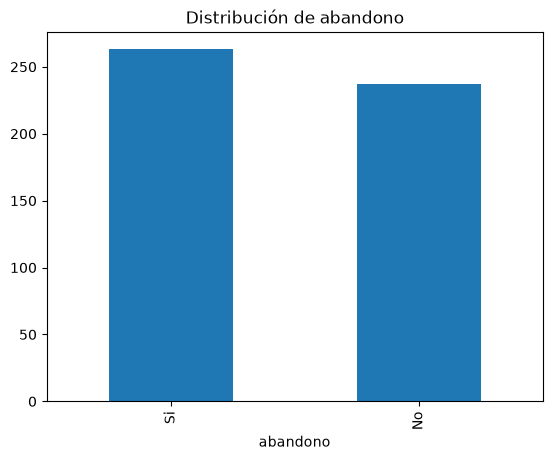

In [5]:
df["abandono"].value_counts().plot(kind="bar")
plt.title("Distribución de abandono")
plt.show()


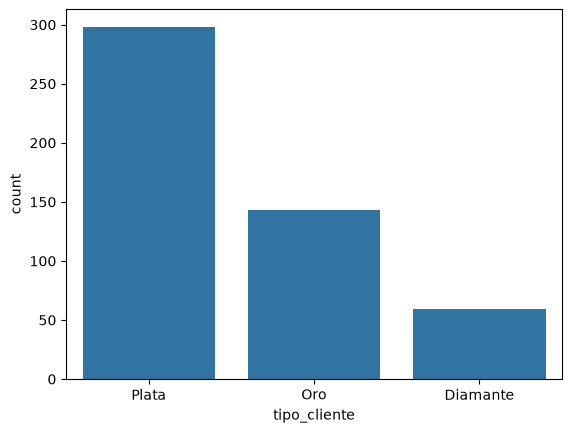

In [6]:
sns.countplot(data=df,x="tipo_cliente")
plt.show()

### Matriz de Correlacion de Pearson
Evalución de correlacion de variables

In [7]:
#Se definen variables a considerar en el mapa de calor
num=df[["monto_promedio_mensual","cantidad_transacciones_mes","frecuencia_uso_app","sesiones_mes","dias_desde_ultimo_login","promociones_abiertas","cantidad_quejas","productos_activos"]]
cor=num.corr()

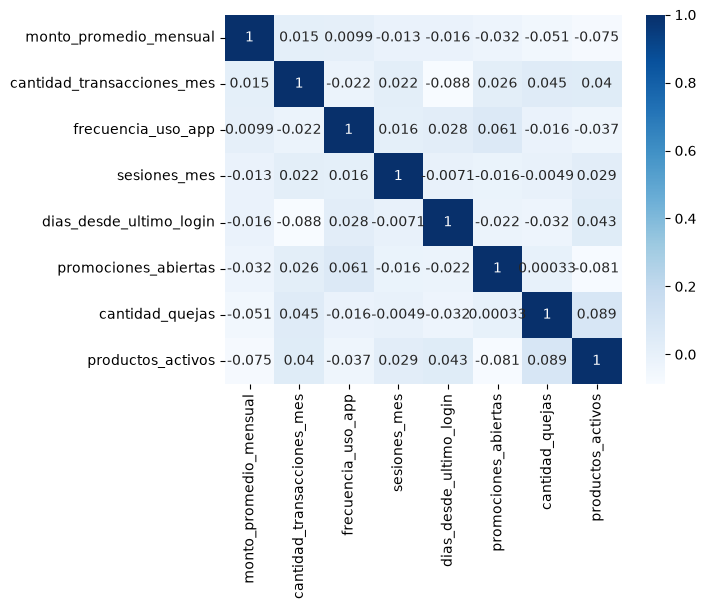

In [8]:
sns.heatmap(cor,annot=True,cmap="Blues")
plt.show()

### Interpretación técnica
No se observan correlaciones fuertes entre las variables.

## Implementación y comparación de modelos

In [9]:
df_model=df.copy()
# Se excluyen variables de texto (cualitativas) debido a que, cuando entrenas la Regresión Logística, Scikit-Learn solo acepta variables numéricas
df_model = df_model.drop(columns=["cliente_id","genero","rango_edad","distrito","tipo_cliente","tipo_transaccion_frecuente","interaccion_promociones","uso_biometria","notificaciones_activas","uso_pago_servicios","uso_transferencias"])

In [10]:
#Para el caso de la variable que queda tipo str (abandono) se convierte a numerica (1=Si, 0=No)
for c in df_model.columns:
    if df_model[c].dtype=="str":
        df_model[c]=LabelEncoder().fit_transform(df_model[c])

In [11]:
#Comprobación de la variable abandono tipo numerica
print(df_model["abandono"].unique())
print(df_model["abandono"].dtype)

[1 0]
int64


In [12]:
X=df_model.drop("abandono",axis=1)
y=df_model["abandono"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
log_model=LogisticRegression(max_iter=1000)
rf_model=RandomForestClassifier(random_state=42)
log_model.fit(X_train,y_train)
rf_model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [14]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
y_pred_log=log_model.predict(X_test)
y_pred_rf=rf_model.predict(X_test)

In [15]:
metricas=pd.DataFrame({
"Modelo":["Regresión Logística","Random Forest"],
"Accuracy":[accuracy_score(y_test,y_pred_log),accuracy_score(y_test,y_pred_rf)],
"Precision":[precision_score(y_test,y_pred_log),precision_score(y_test,y_pred_rf)],
"Recall":[recall_score(y_test,y_pred_log),recall_score(y_test,y_pred_rf)],
"F1":[f1_score(y_test,y_pred_log),f1_score(y_test,y_pred_rf)]
})
metricas

,Modelo,Accuracy,Precision,Recall,F1
0,Regresión Logística,0.673333,0.700000,0.691358,0.695652
1,Random Forest,0.673333,0.686047,0.728395,0.706587


In [16]:
print(confusion_matrix(y_test,y_pred_log))
print(confusion_matrix(y_test,y_pred_rf))

[[45 24]
 [25 56]]
[[42 27]
 [22 59]]


### Interpretación
Comparar Accuracy, Precision, Recall y F1 permite identificar qué modelo clasifica mejor a los clientes con riesgo de abandono. La matriz de confusión ayuda a evaluar aciertos y errores de clasificación.

## Análisis de límites y riesgos

### Riesgos del modelo
- Overfitting: el modelo podría aprender patrones específicos del dataset y perder capacidad de generalización.
- Sesgo: si ciertos segmentos están sobrerrepresentados, las predicciones podrían favorecer a unos grupos más que a otros.
- Interpretabilidad: Random Forest puede ser más difícil de explicar que una Regresión Logística.

### Impacto de datos no representativos
Si los clientes del dataset no representan el comportamiento real de toda la población, el modelo podría producir predicciones poco confiables al implementarse en producción.

### Efecto de outliers
En la muestra de datos no se existen valores atípicos en variables como monto promedio mensual o número de transacciones, pero si existieran en el futuro, podrían afectar el entrenamiento y generar predicciones menos precisas.

## Consideraciones éticas

### ¿Podría el modelo generar sesgos o discriminación?
Sí. Si determinadas características están asociadas a grupos específicos de clientes, el modelo podría aprender patrones discriminatorios. Por ello es importante monitorear los resultados y revisar periódicamente su desempeño.

### ¿Cómo garantizar transparencia para los stakeholders?
Documentando las variables utilizadas, justificando la selección del modelo y comunicando claramente el significado de las métricas obtenidas.

### ¿Qué consideraciones de privacidad aplican?
En este modelo se protege la información de los clientes, no se exponen variables que identifiquen particularmente a ningún cliente.

## Conclusión y recomendación final

### Modelo recomendado y justificación
La Regresión Logística se recomienda como punto de partida por su facilidad de interpretación y capacidad para explicar los factores asociados al abandono.

### Alineación con objetivos estratégicos
El modelo contribuye a identificar clientes con riesgo de fuga para ejecutar acciones de retención y mejorar la adopción de canales digitales.

### Posibles mejoras o siguientes pasos
- Incorporar nuevas variables de comportamiento digital.
- Validar el modelo con datos reales.
- Comparar más algoritmos.
- Implementar monitoreo continuo del desempeño del modelo.